<a href="https://colab.research.google.com/github/RatchanonPa/Data-Warehouse-and-Big-Data-Analytics/blob/main/Data_Mining_Final_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# prompt: connect to ggdrive

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
pd.set_option("display.max_columns", None)

# Load data


In [3]:
train = pd.read_csv('/content/drive/MyDrive/bsc_dpdm24_data/train_set.csv')
train

,id number,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|,Thal_Group
0,67d169,25.0,11.1,34.0,78.0,3.2,0.0,55.9,4.358974,25.464706,32.647059,40.341026,18.141026,2.0,1.535294,3.070588,Abnormal_variants
1,67l168,32.0,13.9,42.0,86.0,3.7,0.3,54.8,5.197674,28.859060,33.557047,35.802326,5.802326,6.0,1.859060,11.154362,Abnormal_variants
2,67i267,43.0,10.1,31.0,78.0,2.6,0.3,56.2,3.974359,25.412903,32.580645,43.725641,23.525641,2.0,1.587097,3.174194,Abnormal_variants
3,67e248,33.0,12.9,38.0,76.0,3.0,0.2,61.2,5.000000,25.800000,33.947368,32.300000,6.500000,4.0,1.200000,4.800000,Abnormal_variants
4,67h277,23.0,12.9,40.0,78.0,3.1,0.0,55.6,5.128205,25.155000,32.250000,34.171795,8.371795,2.0,1.845000,3.690000,Abnormal_variants
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4317,66z431,63.0,10.1,31.0,83.0,2.8,1.8,84.2,3.734940,27.041935,32.580645,48.965060,28.765060,3.0,0.041935,0.125806,Normal
4318,66z436,19.0,11.1,34.0,79.0,2.6,0.6,78.0,4.303797,25.791176,32.647059,41.396203,19.196203,1.0,1.208824,1.208824,Normal
4319,66z439,80.0,10.9,33.9,79.0,3.0,0.2,87.2,4.291139,25.401180,32.153392,42.008861,20.208861,1.0,1.598820,1.598820,Normal
4320,66z445,27.0,13.2,41.4,87.0,2.9,0.3,87.6,4.758621,27.739130,31.884058,42.641379,16.241379,7.0,0.739130,5.173913,Normal


In [4]:
test = pd.read_csv('/content/drive/MyDrive/bsc_dpdm24_data/X_test.csv')
test

,id number,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|
0,66z133,38.0,12.4,37.00,78.0,2.7,1.3,75.4,4.743590,26.140541,33.513514,36.056410,11.256410,2.0,0.859459,1.718919
1,66z297,28.0,12.8,39.40,82.0,2.7,0.0,97.3,4.804878,26.639594,32.487310,38.795122,13.195122,2.0,0.360406,0.720812
2,66u491,78.0,10.9,33.90,79.0,3.1,0.0,96.9,4.291139,25.401180,32.153392,42.008861,20.208861,1.0,1.598820,1.598820
3,66x072,65.0,10.9,33.90,79.0,3.0,0.2,87.9,4.291139,25.401180,32.153392,42.008861,20.208861,1.0,1.598820,1.598820
4,67m031,17.0,11.5,36.00,78.0,2.8,0.8,79.6,4.615385,24.916667,31.944444,38.884615,15.884615,2.0,2.083333,4.166667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1992,67j317,NaN,8.4,26.00,59.0,2.6,0.7,0.3,4.406780,19.061538,32.307692,29.393220,12.593220,21.0,7.938462,166.707692
1993,66a385,NaN,10.1,31.00,78.0,3.3,0.0,55.0,3.974359,25.412903,32.580645,43.725641,23.525641,2.0,1.587097,3.174194
1994,67g355,53.0,10.4,34.00,77.0,3.0,0.2,49.6,4.415584,23.552941,30.588235,41.384416,20.584416,3.0,3.447059,10.341176
1995,66s121,54.0,10.1,31.00,78.0,2.4,0.3,42.0,3.974359,25.412903,32.580645,43.725641,23.525641,2.0,1.587097,3.174194


# Preprocessing

In [11]:
print(train.shape)
print(train.columns)
train.duplicated().sum()

(4322, 17)
Index(['id number', 'Xn', 'Hb(Gm%)', 'Hct(%)', 'MCV(fl)', 'A2 (2-3%)',
       'HbF (2%)', 'HbA (95-97%)', 'RBC', 'MCH', 'MCHC', 'MCV-RBC-3*HGB',
       'MCV-RBC-5*HGB', '|80-MCV|', '|27-MCH|', '|80-MCV|*|27-MCH|',
       'Thal_Group'],
      dtype='object')


0

In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4322 entries, 0 to 4321
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id number          4322 non-null   object 
 1   Xn                 3887 non-null   float64
 2   Hb(Gm%)            4315 non-null   float64
 3   Hct(%)             4315 non-null   float64
 4   MCV(fl)            4315 non-null   float64
 5   A2 (2-3%)          4189 non-null   float64
 6   HbF (2%)           4206 non-null   float64
 7   HbA (95-97%)       4206 non-null   float64
 8   RBC                4315 non-null   float64
 9   MCH                4315 non-null   float64
 10  MCHC               4315 non-null   float64
 11  MCV-RBC-3*HGB      4315 non-null   float64
 12  MCV-RBC-5*HGB      4315 non-null   float64
 13  |80-MCV|           4315 non-null   float64
 14  |27-MCH|           4315 non-null   float64
 15  |80-MCV|*|27-MCH|  4315 non-null   float64
 16  Thal_Group         4322 

In [21]:
train.describe()

,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|
count,3887.000000,4315.000000,4315.000000,4315.000000,4189.000000,4206.000000,4206.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000,4315.000000
mean,40.510059,10.370717,32.448678,70.919177,11.530902,1.497967,80.268503,4.635384,22.654757,31.857088,34.924984,14.108856,10.002491,4.556300,72.895320
std,24.383982,1.997339,5.512625,9.471956,18.457527,5.985359,22.044018,0.789678,3.652130,1.543573,9.254880,10.762377,8.631753,3.427993,91.344636
min,0.000000,1.600000,3.700000,43.000000,0.000000,0.000000,0.000000,0.395062,8.703704,17.407407,4.967967,-20.333070,0.000000,0.000000,0.000000
25%,24.000000,9.400000,30.000000,64.000000,2.400000,0.000000,74.200000,4.291139,19.732143,30.947042,28.426374,7.420635,2.000000,1.598820,1.598820
50%,36.000000,10.700000,33.000000,73.000000,2.900000,0.400000,86.500000,4.605263,23.594248,32.153392,35.306897,12.894737,8.000000,3.654545,27.000000
75%,62.000000,11.350000,35.000000,79.000000,16.500000,1.100000,96.000000,5.079365,25.401180,32.727273,42.008861,20.208861,17.000000,7.267857,118.400000
max,97.000000,19.600000,53.100000,109.000000,100.000000,99.200000,118.900000,7.742601,36.364999,36.969697,83.949485,76.149485,43.000000,18.296296,548.888889


In [9]:
train.isnull().sum()

,0
id number,0
Xn,435
Hb(Gm%),7
Hct(%),7
MCV(fl),7
A2 (2-3%),133
HbF (2%),116
HbA (95-97%),116
RBC,7
MCH,7


In [12]:
set(train['Thal_Group'])

{'Abnormal_variants',
 'Alpha_thal_related',
 'Beta_thal_related',
 'Complex_genotypes',
 'HbE_related',
 'Normal'}

In [ ]:
# prompt: map train['Thal_Group'] value {'Abnormal_variants',
#  'Alpha_thal_related',
#  'Beta_thal_related',
#  'Complex_genotypes',
#  'HbE_related',
#  'Normal'}

train['Thal_Group'] = train['Thal_Group'].map({'Abnormal_variants': 'Abnormal_variants',
                                               'Alpha_thal_related': 'Alpha_thal_related',
                                               'Beta_thal_related': 'Beta_thal_related',
                                               'Complex_genotypes': 'Complex_genotypes',
                                               'HbE_related': 'HbE_related',
                                               'Normal': 'Normal'})


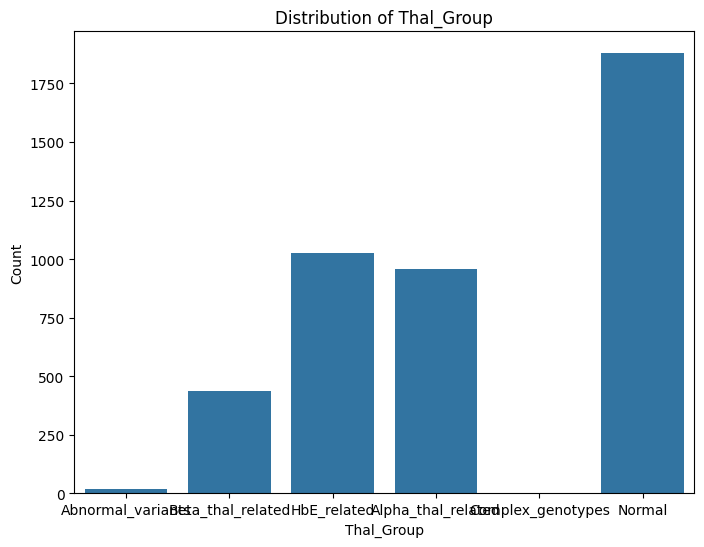

In [13]:
# prompt: visualize train['Thal_Group']

import matplotlib.pyplot as plt
# Visualize Thal_Group
plt.figure(figsize=(8, 6))
sns.countplot(x='Thal_Group', data=train)
plt.title('Distribution of Thal_Group')
plt.xlabel('Thal_Group')
plt.ylabel('Count')
plt.show()


In [19]:
# prompt: group by train['Thal_Group']

# Group data by 'Thal_Group'
grouped_thal = train.groupby('Thal_Group')

# Print some descriptive statistics for each group
grouped_thal.count()


,id number,Xn,Hb(Gm%),Hct(%),MCV(fl),A2 (2-3%),HbF (2%),HbA (95-97%),RBC,MCH,MCHC,MCV-RBC-3*HGB,MCV-RBC-5*HGB,|80-MCV|,|27-MCH|,|80-MCV|*|27-MCH|
Thal_Group,,,,,,,,,,,,,,,,
Abnormal_variants,18,17,18,18,18,18,18,18,18,18,18,18,18,18,18,18
Alpha_thal_related,959,866,955,955,955,891,898,898,955,955,955,955,955,955,955,955
Beta_thal_related,439,397,438,438,438,432,434,434,438,438,438,438,438,438,438,438
Complex_genotypes,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
HbE_related,1025,942,1023,1023,1023,1021,1021,1021,1023,1023,1023,1023,1023,1023,1023,1023
Normal,1878,1662,1878,1878,1878,1824,1832,1832,1878,1878,1878,1878,1878,1878,1878,1878


In [20]:
grouped_thal.describe()

Xn                                                     \
                     count       mean        std  min   25%   50%   75%   max   
Thal_Group                                                                      
Abnormal_variants     17.0  40.529412  23.294628  3.0  31.0  39.0  43.0  88.0   
Alpha_thal_related   866.0  41.330254  25.740940  0.0  22.0  39.0  64.0  92.0   
Beta_thal_related    397.0  46.324937  28.496016  0.0  24.0  55.0  70.0  97.0   
Complex_genotypes      3.0  32.666667  34.645827  0.0  14.5  29.0  49.0  69.0   
HbE_related          942.0  35.488960  20.047084  0.0  23.0  32.0  43.0  90.0   
Normal              1662.0  41.553550  24.374397  0.0  25.0  39.0  63.0  97.0   

                   Hb(Gm%)                                                  \
                     count       mean       std  min     25%   50%     75%   
Thal_Group                                                                   
Abnormal_variants     18.0  11.105556  1.659366  8.4  10.100  10.6  12.575   
Alpha_thal_related   955.0   9.530366  1.662981  3.8   8.400   9.8  10.200   
Beta_thal_related    438.0   9.790970  1.190078  1.6   9.525  10.1  10.100   
Complex_genotypes      3.0   9.933333  2.309401  8.6   8.600   8.6  10.600   
HbE_related         1023.0  11.333333  1.973456  4.0  10.400  11.7  12.300   
Normal              1878.0  10.402556  2.081638  3.1   9.300  10.9  10.900   

                          Hct(%)                                          \
                     max   count       mean       std   min   25%    50%   
Thal_Group                                                                 
Abnormal_variants   13.9    18.0  33.650000  4.879398  26.0  31.0  31.85   
Alpha_thal_related  13.5   955.0  30.960775  4.937600  13.0  28.0  31.80   
Beta_thal_related   13.3   438.0  31.048630  3.558792   5.0  30.0  32.00   
Complex_genotypes   12.6     3.0  31.666667  6.350853  28.0  28.0  28.00   
HbE_related         16.1  1023.0  34.428353  5.665802  14.3  31.0  35.00   
Normal              19.6  1878.0  32.443184  5.747411   3.7  30.0  33.90   

                               MCV(fl)                                         \
                     75%   max   count       mean       std   min   25%   50%   
Thal_Group                                                                      
Abnormal_variants   37.0  42.0    18.0  79.625000  3.869422  71.0  78.0  78.0   
Alpha_thal_related  33.0  42.8   955.0  63.160471  6.012715  47.0  60.0  64.0   
Beta_thal_related   32.0  42.3   438.0  63.642123  4.023093  46.0  63.0  63.0   
Complex_genotypes   33.5  39.0     3.0  67.000000  1.732051  66.0  66.0  66.0   
HbE_related         37.0  49.1  1023.0  72.130499  8.779957  45.0  69.0  76.0   
Normal              33.9  53.1  1878.0  75.824814  8.563510  43.0  74.0  79.0   

                                 A2 (2-3%)                              \
                      75%    max     count       mean        std   min   
Thal_Group                                                               
Abnormal_variants   82.75   86.0      18.0   3.227778   0.425379   2.3   
Alpha_thal_related  66.00   88.0     891.0   6.374747  15.155143   0.0   
Beta_thal_related   63.00   81.0     432.0   5.626389   0.683480   2.1   
Complex_genotypes   67.50   69.0       3.0  21.166667   0.404145  20.8   
HbE_related         77.00   88.0    1021.0  34.582174  21.999893   5.7   
Normal              79.00  109.0    1824.0   2.610992   0.554732   0.5   

                                               HbF (2%)                       \
                       25%   50%    75%    max    count      mean        std   
Thal_Group                                                                     
Abnormal_variants    2.925   3.2   3.65    3.9     18.0  0.188889   0.234869   
Alpha_thal_related   1.750   2.4   2.70   82.0    898.0  2.888781   9.678496   
Beta_thal_related    5.300   5.6   6.00    8.3    434.0  3.213076  11.297123   
Complex_genotypes   20.950  2